In [85]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, matthews_corrcoef
from sklearn.preprocessing import StandardScaler

In [27]:
datafile = "../iris.csv"
df = pd.read_csv(datafile, header = 0)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [28]:
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
x = df[feature_cols]
y = df.species

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1) 

In [30]:
classifier = DecisionTreeClassifier()
classifier = classifier.fit(x_train,y_train)
y_pred = classifier.predict(x_test)

In [93]:
print("Accuracy:",accuracy_score(y_test, y_pred))


Accuracy: 0.9555555555555556


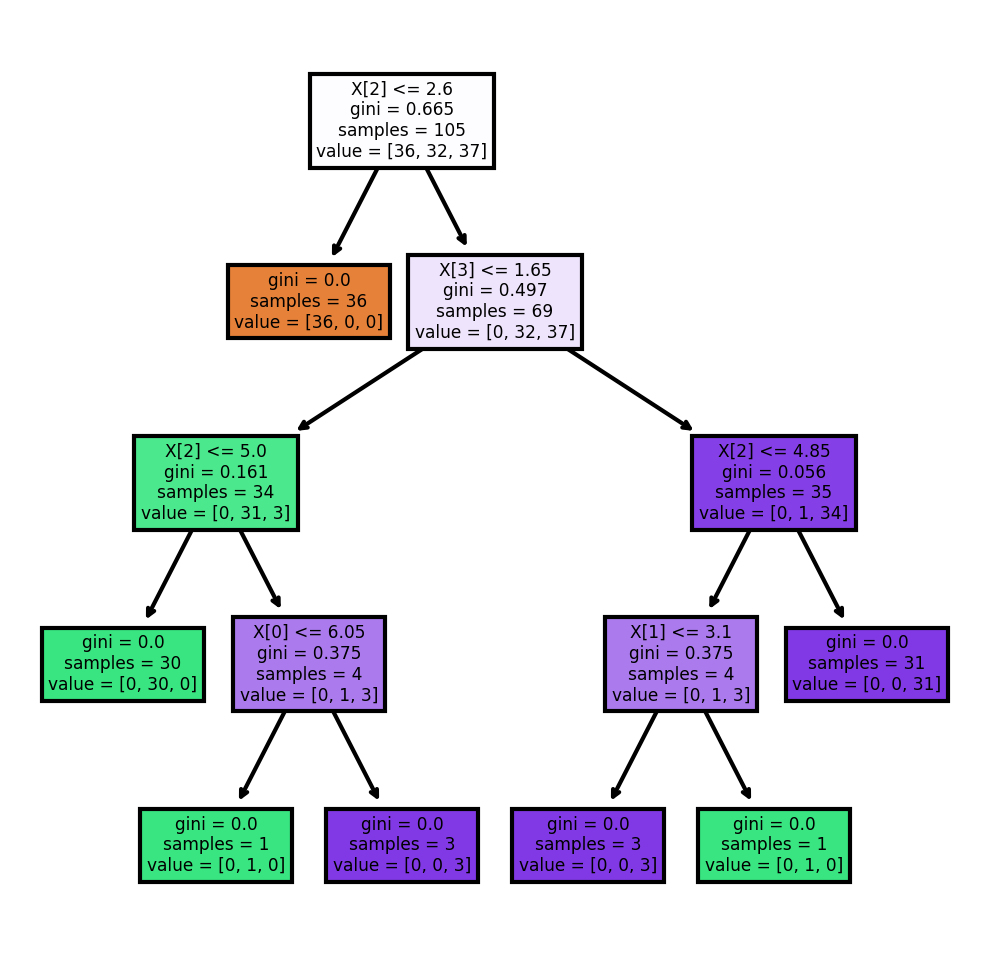

In [33]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
tree.plot_tree(classifier, filled=True)
plt.show()

In [37]:
param_grid = {'criterion': ("gini", "entropy"), 
              'max_depth': (3, 4, 5, 10, 20, None)}

In [38]:
classifier_grid = GridSearchCV(classifier, param_grid, cv=5)

In [39]:
classifier_grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ('gini', 'entropy'),
                         'max_depth': (3, 4, 5, 10, 20, None)})

In [41]:
classifier_grid.best_params_

{'criterion': 'gini', 'max_depth': 3}

In [44]:
classifier_grid.best_score_

0.9523809523809523

In [54]:
classifier = DecisionTreeClassifier(criterion = 'gini', max_depth = 3)
classifier = classifier.fit(x_train,y_train)
y_pred = classifier.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9555555555555556


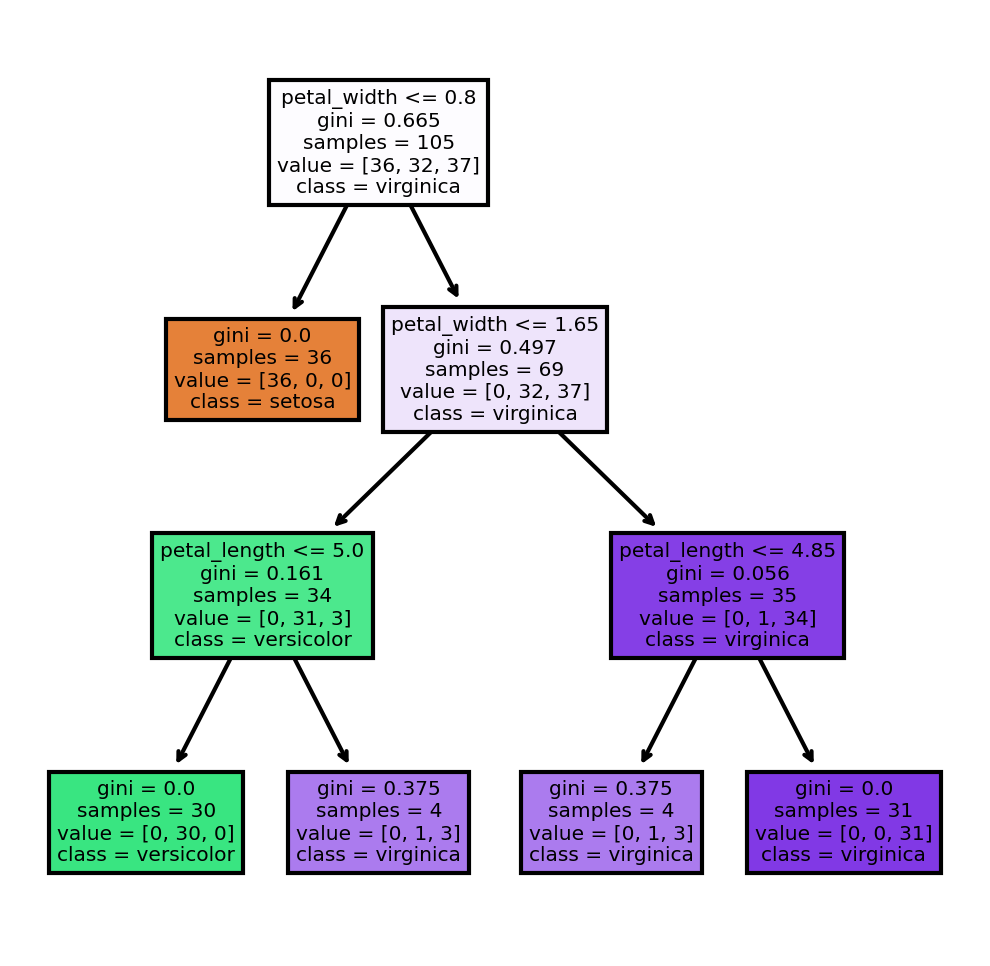

In [62]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
tree.plot_tree(classifier, filled=True, feature_names=x.columns, class_names=classifier.classes_)
plt.show()

In [63]:
print(confusion_matrix(y_test, y_pred))  

[[14  0  0]
 [ 0 17  1]
 [ 0  1 12]]


In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.94      0.94      0.94        18
   virginica       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support

In [86]:
matthews_corrcoef(y_test, y_pred)

0.9326347305389222

In [91]:
df.corr() #Pearson

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


In [92]:
df.corr(method="spearman") #Spearman

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.159457,0.881386,0.834421
sepal_width,-0.159457,1.000000,-0.303421,-0.277511
petal_length,0.881386,-0.303421,1.000000,0.936003
petal_width,0.834421,-0.277511,0.936003,1.000000
